成功加载中文字体：Microsoft YaHei
正在读取数据文件：../dangdang_analysis_data/featured_dangdang_data.csv
成功读取数据，使用编码：gbk
数据形状：(56395, 52)

📚 生成图书类别分布图...
图表已保存：dang_dang_html\01_图书类别分布分析.png


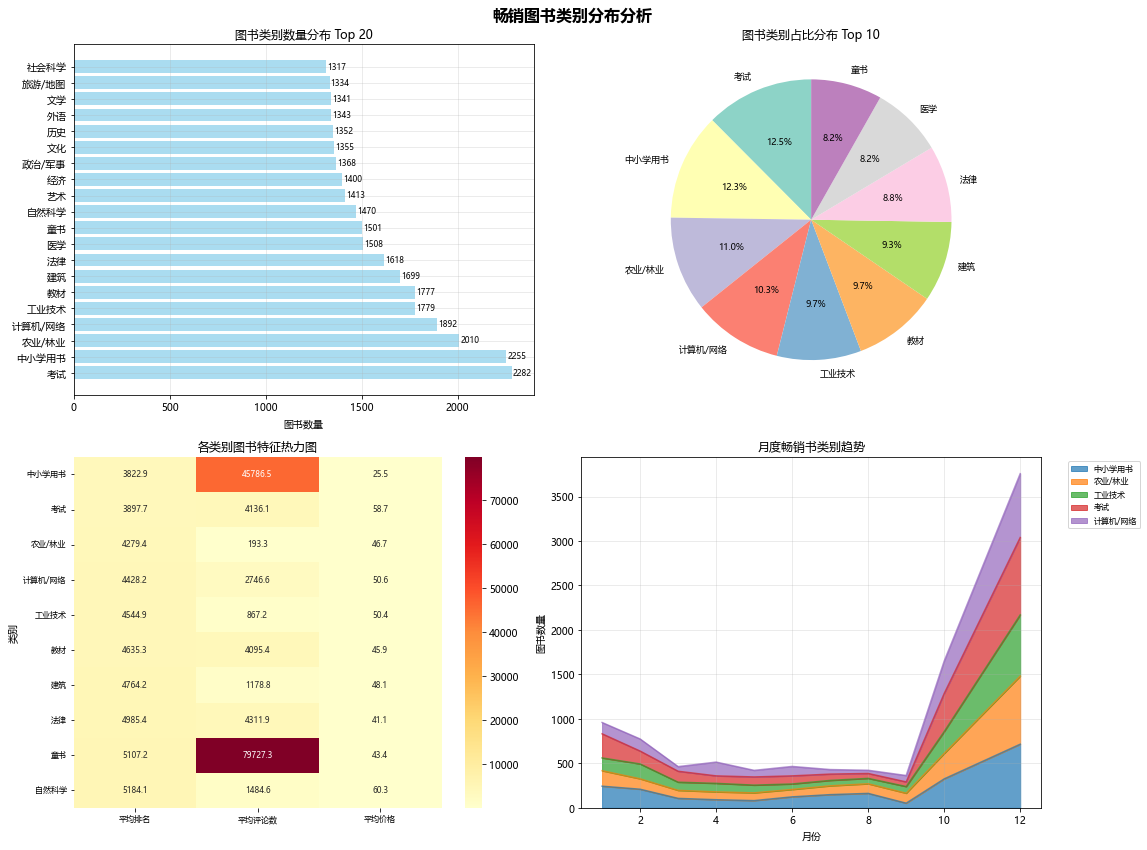


📊 类别分析结果：
- 总类别数：43
- 前5大类：
  1. 考试：2282本
  2. 中小学用书：2255本
  3. 农业/林业：2010本
  4. 计算机/网络：1892本
  5. 工业技术：1779本
✅ 图书类别分布分析完成！

🎉 所有分析完成！
📁 图表保存目录：dang_dang_html


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
from pathlib import Path

class BookAnalysis:
    def __init__(self, data_path):
        """初始化分析类"""
        self.data_path = data_path
        self.data = None
        self.analysis_results = {}
        self.output_dir = "dang_dang_html"
        
        # 初始化配置
        self._init_config()
        
    def _init_config(self):
        """初始化配置"""
        # 创建输出目录
        Path(self.output_dir).mkdir(parents=True, exist_ok=True)
        
        # 设置中文字体
        font_path = 'C:/Windows/Fonts/msyh.ttc'  # Windows系统
        if os.path.exists(font_path):
            font_prop = mpl.font_manager.FontProperties(fname=font_path)
            plt.rcParams['font.family'] = font_prop.get_name()
            plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
            print(f"成功加载中文字体：{font_prop.get_name()}")
        else:
            # 尝试其他常见中文字体
            for font_name in ['SimHei', 'Microsoft YaHei', 'Heiti TC']:
                try:
                    plt.rcParams['font.family'] = font_name
                    plt.rcParams['axes.unicode_minus'] = False
                    print(f"成功加载中文字体：{font_name}")
                    break
                except:
                    continue
    
    def load_data(self):
        """加载数据"""
        print(f"正在读取数据文件：{self.data_path}")
        try:
            # 尝试不同编码读取
            encodings = ['gbk', 'gb18030', 'utf-8', 'latin-1']
            for encoding in encodings:
                try:
                    self.data = pd.read_csv(self.data_path, encoding=encoding)
                    print(f"成功读取数据，使用编码：{encoding}")
                    print(f"数据形状：{self.data.shape}")
                    return True
                except Exception as e:
                    print(f"使用编码 {encoding} 读取失败：{str(e)[:100]}")
                    continue
            
            print("所有编码尝试失败，使用默认编码")
            self.data = pd.read_csv(self.data_path)
            return True
            
        except Exception as e:
            print(f"数据读取失败：{e}")
            return False
    
    def _save_plot(self, filename, fig):
        """保存图表"""
        filepath = os.path.join(self.output_dir, filename)
        fig.savefig(filepath, dpi=150, bbox_inches='tight')
        print(f"图表已保存：{filepath}")
    
    def plot_category_distribution(self):
        """畅销图书类别分布分析"""
        print("\n📚 生成图书类别分布图...")
        
        if self.data is None:
            print("❌ 数据未加载")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('畅销图书类别分布分析', fontsize=16, fontweight='bold')
        
        # 1. 图书类别数量分布（前20）
        if '图书类别' in self.data.columns:
            category_counts = self.data['图书类别'].value_counts().head(20)
            
            axes[0, 0].barh(range(len(category_counts)), category_counts.values, 
                          color='skyblue', alpha=0.7)
            axes[0, 0].set_yticks(range(len(category_counts)))
            axes[0, 0].set_yticklabels(category_counts.index, fontsize=10)
            axes[0, 0].set_title('图书类别数量分布 Top 20', fontsize=12)
            axes[0, 0].set_xlabel('图书数量', fontsize=10)
            axes[0, 0].grid(True, alpha=0.3)
            
            # 在柱状图上添加数值
            for i, v in enumerate(category_counts.values):
                axes[0, 0].text(v + 5, i, str(v), va='center', fontsize=8)
        
        # 2. 图书类别饼图（前10）
        if '图书类别' in self.data.columns:
            top_categories = self.data['图书类别'].value_counts().head(10)
            colors = plt.cm.Set3(range(len(top_categories)))
            axes[0, 1].pie(top_categories.values, labels=top_categories.index,
                          autopct='%1.1f%%', startangle=90, 
                          textprops={'fontsize': 9}, colors=colors)
            axes[0, 1].set_title('图书类别占比分布 Top 10', fontsize=12)
        
        # 3. 不同类别的平均排名热力图
        if '图书类别' in self.data.columns and '排序' in self.data.columns:
            category_rank = self.data.groupby('图书类别')['排序'].mean().sort_values()
            top_categories_rank = category_rank.head(10)
            
            # 创建热力图数据
            heatmap_data = []
            for category in top_categories_rank.index:
                category_data = self.data[self.data['图书类别'] == category]
                row_data = {
                    '类别': category,
                    '平均排名': category_rank[category],
                    '图书数量': len(category_data)
                }
                if '评论数' in category_data.columns:
                    row_data['平均评论数'] = category_data['评论数'].mean()
                if '原价' in category_data.columns:
                    row_data['平均价格'] = category_data['原价'].mean()
                
                heatmap_data.append(row_data)
            
            if heatmap_data:
                heatmap_df = pd.DataFrame(heatmap_data)
                heatmap_df = heatmap_df.set_index('类别')
                
                # 选择要显示的列
                display_cols = []
                if '平均排名' in heatmap_df.columns:
                    display_cols.append('平均排名')
                if '平均评论数' in heatmap_df.columns:
                    display_cols.append('平均评论数')
                if '平均价格' in heatmap_df.columns:
                    display_cols.append('平均价格')
                
                if display_cols:
                    sns.heatmap(heatmap_df[display_cols],
                              annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1, 0],
                              annot_kws={'fontsize': 8})
                    axes[1, 0].set_title('各类别图书特征热力图', fontsize=12)
                    axes[1, 0].tick_params(axis='x', labelsize=8)
                    axes[1, 0].tick_params(axis='y', labelsize=8)
        
        # 4. 月度榜单类别趋势（简化版）
        if '图书类别' in self.data.columns and '月份' in self.data.columns:
            # 确保月份是数值类型
            self.data['月份'] = pd.to_numeric(self.data['月份'], errors='coerce')
            
            top_categories = self.data['图书类别'].value_counts().head(5).index
            monthly_common = self.data[self.data['图书类别'].isin(top_categories)]
            
            if not monthly_common.empty:
                monthly_pivot = pd.crosstab(monthly_common['月份'], monthly_common['图书类别'])
                monthly_pivot.plot(kind='area', stacked=True, ax=axes[1, 1], alpha=0.7)
                axes[1, 1].set_title('月度畅销书类别趋势', fontsize=12)
                axes[1, 1].set_xlabel('月份', fontsize=10)
                axes[1, 1].set_ylabel('图书数量', fontsize=10)
                axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
                axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        self._save_plot('01_图书类别分布分析.png', fig)
        plt.show()
        
        # 保存分析结果
        if '图书类别' in self.data.columns:
            self.analysis_results['category_stats'] = {
                'total_categories': self.data['图书类别'].nunique(),
                'top_categories': self.data['图书类别'].value_counts().head(10).to_dict()
            }
            print(f"\n📊 类别分析结果：")
            print(f"- 总类别数：{self.data['图书类别'].nunique()}")
            print(f"- 前5大类：")
            for i, (cat, count) in enumerate(self.data['图书类别'].value_counts().head(5).items(), 1):
                print(f"  {i}. {cat}：{count}本")
        
        print("✅ 图书类别分布分析完成！")


# 主程序入口
if __name__ == "__main__":
    # 数据文件路径（请根据实际情况修改）
    DATA_FILE = "../dangdang_analysis_data/featured_dangdang_data.csv"
    
    # 创建分析实例
    analyzer = BookAnalysis(DATA_FILE)
    
    # 加载数据
    if analyzer.load_data():
        # 执行类别分布分析
        analyzer.plot_category_distribution()
        
        print("\n" + "="*60)
        print("🎉 所有分析完成！")
        print(f"📁 图表保存目录：{analyzer.output_dir}")
        print("="*60)
    else:
        print("❌ 程序执行失败：数据加载失败")

成功加载中文字体：Microsoft YaHei

正在读取数据文件：../dangdang_analysis_data/featured_dangdang_data.csv
数据读取成功！编码：gbk，数据形状：(56395, 52)

💰 生成价格分析图...
图表已保存：dang_dang_html\02_价格分析.png


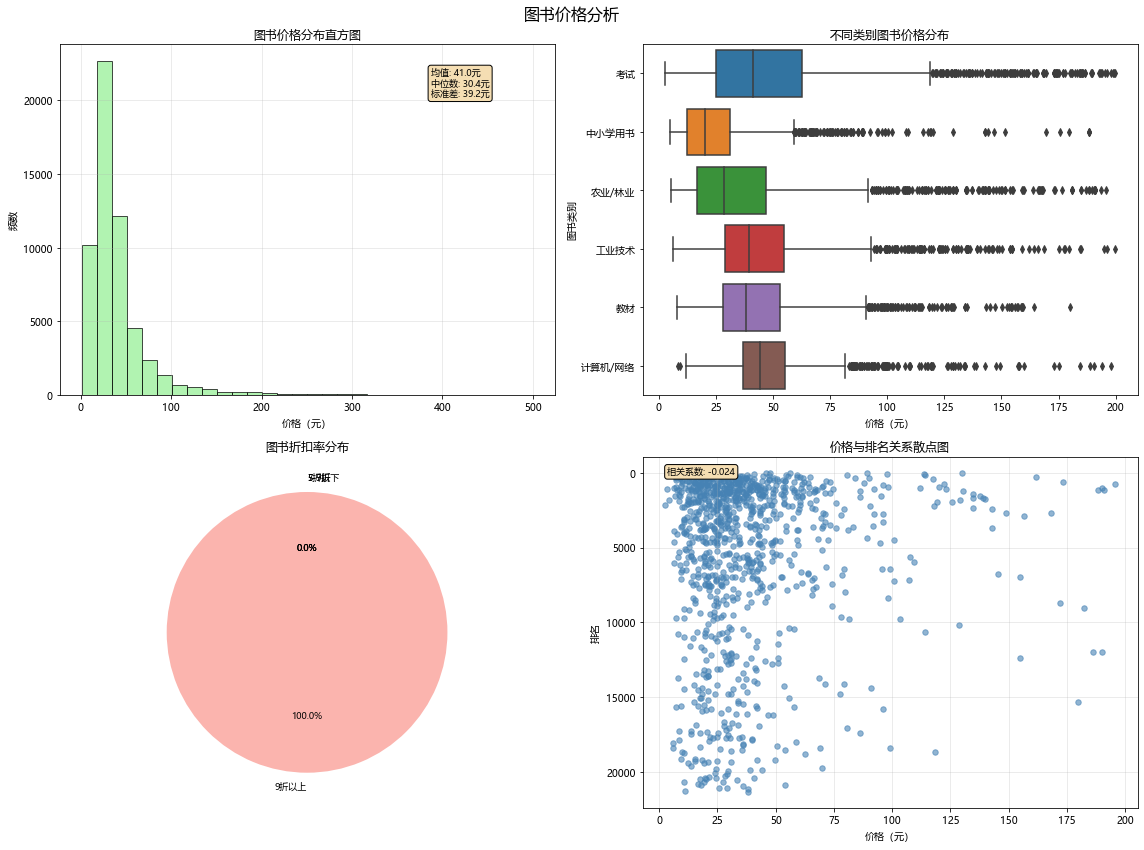


📊 价格分析关键结果：
- 平均价格：41.7元
- 中位数价格：30.4元
- 价格标准差：44.6元
- 价格与排名相关系数：-0.024
✅ 价格分析完成！

🎉 价格分析全流程完成！
📁 图表保存路径：dang_dang_html/02_价格分析.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
from pathlib import Path

class BookAnalysis:
    def __init__(self, data_path):
        """初始化分析类"""
        self.data_path = data_path
        self.data = None
        self.analysis_results = {}
        self.output_dir = "dang_dang_html"
        self.font_prop = None  # 字体对象
        
        # 初始化配置（编码适配+中文显示）
        self._init_config()
        
    def _init_config(self):
        """初始化配置：创建目录、设置中文字体"""
        # 创建输出目录
        Path(self.output_dir).mkdir(parents=True, exist_ok=True)
        
        # 设置中文字体（解决中文显示问题）
        font_path = 'C:/Windows/Fonts/msyh.ttc'  # Windows默认微软雅黑路径
        if os.path.exists(font_path):
            self.font_prop = mpl.font_manager.FontProperties(fname=font_path)
            plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示异常
            print(f"成功加载中文字体：{self.font_prop.get_name()}")
        else:
            # 兼容其他系统中文字体
            fallback_fonts = ['SimHei', 'Microsoft YaHei', 'Heiti TC', 'DejaVu Sans']
            for font in fallback_fonts:
                try:
                    plt.rcParams['font.family'] = font
                    plt.rcParams['axes.unicode_minus'] = False
                    print(f"成功加载 fallback 中文字体：{font}")
                    break
                except:
                    continue
    
    def load_data(self):
        """加载数据（指定gbk编码，解决编码错误）"""
        print(f"\n正在读取数据文件：{self.data_path}")
        try:
            # 明确使用gbk编码（适配中文CSV）
            self.data = pd.read_csv(self.data_path, encoding='gbk')
            print(f"数据读取成功！编码：gbk，数据形状：{self.data.shape}")
            return True
        except Exception as e:
            # 编码容错：尝试其他常见中文编码
            print(f"gbk编码读取失败，尝试其他编码：{str(e)[:80]}")
            try:
                self.data = pd.read_csv(self.data_path, encoding='gb18030')
                print("使用gb18030编码读取成功")
                return True
            except:
                print("所有中文编码尝试失败，分析终止")
                return False
    
    def _save_plot(self, filename, fig):
        """保存图表到指定目录"""
        filepath = os.path.join(self.output_dir, filename)
        fig.savefig(filepath, dpi=150, bbox_inches='tight')
        print(f"图表已保存：{filepath}")
    
    def plot_price_analysis(self):
        """价格区间分析（中文显示+数据优化）"""
        print("\n💰 生成价格分析图...")
        
        if self.data is None:
            print("❌ 数据未加载，无法进行价格分析")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('图书价格分析', fontsize=16, fontweight='bold', fontproperties=self.font_prop)

        # 1. 价格分布直方图
        if '原价' in self.data.columns:
            price_data = self.data['原价'].dropna()
            price_data = price_data[price_data <= 500]  # 过滤异常高价
            
            axes[0, 0].hist(price_data, bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
            axes[0, 0].set_title('图书价格分布直方图', fontsize=12, fontproperties=self.font_prop)
            axes[0, 0].set_xlabel('价格（元）', fontsize=10, fontproperties=self.font_prop)
            axes[0, 0].set_ylabel('频数', fontsize=10, fontproperties=self.font_prop)
            axes[0, 0].grid(True, alpha=0.3)
            
            # 添加统计信息（中文适配）
            stats_text = f"均值: {price_data.mean():.1f}元\n中位数: {price_data.median():.1f}元\n标准差: {price_data.std():.1f}元"
            axes[0, 0].text(0.75, 0.85, stats_text, transform=axes[0, 0].transAxes,
                            bbox=dict(boxstyle="round", facecolor='wheat'), 
                            fontsize=9, fontproperties=self.font_prop)

        # 2. 价格箱线图（按Top6类别）
        if '原价' in self.data.columns and '图书类别' in self.data.columns:
            top_categories = self.data['图书类别'].value_counts().head(6).index
            top_categories_data = self.data[self.data['图书类别'].isin(top_categories)]
            top_categories_data = top_categories_data[top_categories_data['原价'] <= 200]  # 过滤异常值
            
            sns.boxplot(data=top_categories_data, x='原价', y='图书类别', ax=axes[0, 1])
            axes[0, 1].set_title('不同类别图书价格分布', fontsize=12, fontproperties=self.font_prop)
            axes[0, 1].set_xlabel('价格（元）', fontsize=10, fontproperties=self.font_prop)
            axes[0, 1].set_ylabel('图书类别', fontsize=10, fontproperties=self.font_prop)
            axes[0, 1].tick_params(axis='y', labelsize=9)
            # 单独设置y轴类别标签字体
            for label in axes[0, 1].get_yticklabels():
                label.set_fontproperties(self.font_prop)

        # 3. 折扣分析饼图
        if '折扣率' in self.data.columns:
            discount_data = self.data['折扣率'].dropna()
            discount_ranges = pd.cut(
                discount_data, 
                bins=[0, 0.5, 0.7, 0.9, 1.0],
                labels=['5折以下', '5-7折', '7-9折', '9折以上']
            )
            discount_counts = discount_ranges.value_counts()
            
            # 饼图文本中文适配
            wedges, texts, autotexts = axes[1, 0].pie(
                discount_counts.values,
                labels=discount_counts.index,
                autopct='%1.1f%%',
                startangle=90,
                textprops={'fontsize': 9, 'fontproperties': self.font_prop},
                colors=plt.cm.Pastel1(np.linspace(0, 1, len(discount_counts)))
            )
            for autotext in autotexts:
                autotext.set_color('black')  # 优化百分比可读性
            
            axes[1, 0].set_title('图书折扣率分布', fontsize=12, fontproperties=self.font_prop)

        # 4. 价格与排名关系散点图
        if '原价' in self.data.columns and '排序' in self.data.columns:
            sample_size = min(1000, len(self.data))
            sample_data = self.data.sample(sample_size, random_state=42)  # 固定种子，结果可复现
            sample_data = sample_data[sample_data['原价'] <= 200]  # 过滤异常值
            
            axes[1, 1].scatter(sample_data['原价'], sample_data['排序'], alpha=0.6, s=30, color='steelblue')
            axes[1, 1].set_xlabel('价格（元）', fontsize=10, fontproperties=self.font_prop)
            axes[1, 1].set_ylabel('排名', fontsize=10, fontproperties=self.font_prop)
            axes[1, 1].set_title('价格与排名关系散点图', fontsize=12, fontproperties=self.font_prop)
            axes[1, 1].grid(True, alpha=0.3)
            axes[1, 1].invert_yaxis()  # 排名越小越靠前，反转y轴更直观
            
            # 计算相关系数（处理缺失值）
            valid_corr_data = self.data[['原价', '排序']].dropna()
            correlation = valid_corr_data['原价'].corr(valid_corr_data['排序']) if len(valid_corr_data) > 0 else 0
            axes[1, 1].text(0.05, 0.95, f'相关系数: {correlation:.3f}',
                            transform=axes[1, 1].transAxes,
                            bbox=dict(boxstyle="round", facecolor='wheat'), 
                            fontsize=9, fontproperties=self.font_prop)

        plt.tight_layout()
        self._save_plot('02_价格分析.png', fig)
        plt.show()

        # 保存价格分析结果
        if '原价' in self.data.columns:
            valid_price_data = self.data['原价'].dropna()
            self.analysis_results['price_stats'] = {
                'mean_price': valid_price_data.mean(),
                'median_price': valid_price_data.median(),
                'std_price': valid_price_data.std(),
                'price_correlation_with_rank': correlation if '排序' in self.data.columns else 0
            }
            
            # 输出关键统计信息
            print(f"\n📊 价格分析关键结果：")
            print(f"- 平均价格：{valid_price_data.mean():.1f}元")
            print(f"- 中位数价格：{valid_price_data.median():.1f}元")
            print(f"- 价格标准差：{valid_price_data.std():.1f}元")
            if '排序' in self.data.columns:
                print(f"- 价格与排名相关系数：{correlation:.3f}")
        
        print("✅ 价格分析完成！")


# 主程序入口（直接运行即可）
if __name__ == "__main__":
    # 数据文件路径（根据实际情况调整）
    DATA_FILE = "../dangdang_analysis_data/featured_dangdang_data.csv"
    
    # 初始化分析实例
    analyzer = BookAnalysis(DATA_FILE)
    
    # 加载数据（自动处理编码问题）
    if analyzer.load_data():
        # 执行价格分析（自动处理中文显示）
        analyzer.plot_price_analysis()
        
        print("\n" + "="*60)
        print("🎉 价格分析全流程完成！")
        print(f"📁 图表保存路径：{analyzer.output_dir}/02_价格分析.png")
        print("="*60)
    else:
        print("❌ 程序执行失败：数据加载失败（编码错误或文件路径错误）")

成功加载中文字体：Microsoft YaHei

正在读取数据文件：../dangdang_analysis_data/featured_dangdang_data.csv
数据读取成功！编码：gbk，数据形状：(56395, 52)

📈 生成销量与评分相关性分析图...
图表已保存：dang_dang_html\03_销量评分相关性分析.png


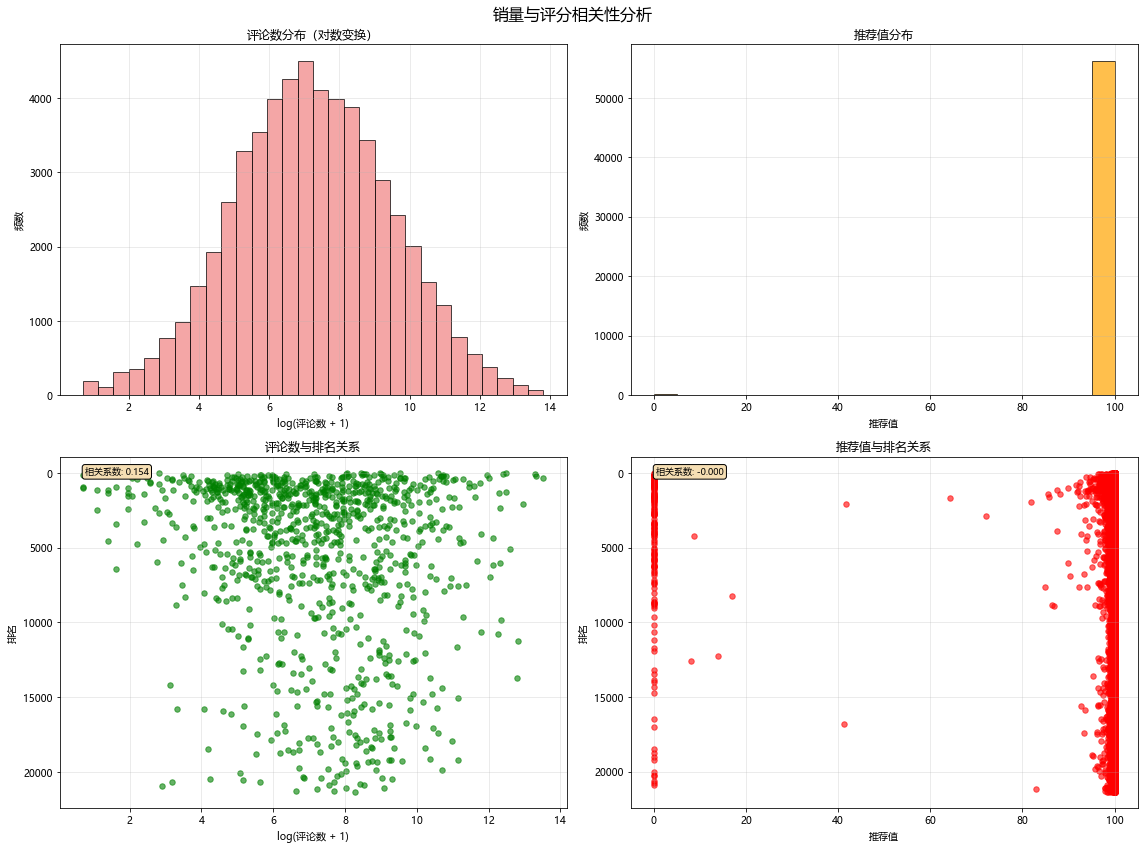


📊 相关性分析关键结果：
- 对数评论数与排名相关系数：0.154
- 原始评论数与排名相关系数：-0.008
- 推荐值与排名相关系数：-0.000
✅ 销量与评分相关性分析完成！

🎉 销量与评分相关性分析全流程完成！
📁 图表保存路径：dang_dang_html/03_销量评分相关性分析.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
from pathlib import Path

class BookAnalysis:
    def __init__(self, data_path):
        """初始化分析类"""
        self.data_path = data_path
        self.data = None
        self.analysis_results = {}
        self.output_dir = "dang_dang_html"
        self.font_prop = None  # 中文字体对象
        
        # 初始化配置（编码适配+中文显示）
        self._init_config()
        
    def _init_config(self):
        """初始化配置：创建目录、设置中文字体"""
        # 创建输出目录
        Path(self.output_dir).mkdir(parents=True, exist_ok=True)
        
        # 解决中文显示问题
        font_path = 'C:/Windows/Fonts/msyh.ttc'  # Windows默认微软雅黑路径
        if os.path.exists(font_path):
            self.font_prop = mpl.font_manager.FontProperties(fname=font_path)
            plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示异常
            print(f"成功加载中文字体：{self.font_prop.get_name()}")
        else:
            # 兼容其他系统中文字体
            fallback_fonts = ['SimHei', 'Microsoft YaHei', 'Heiti TC', 'DejaVu Sans']
            for font in fallback_fonts:
                try:
                    plt.rcParams['font.family'] = font
                    plt.rcParams['axes.unicode_minus'] = False
                    print(f"成功加载 fallback 中文字体：{font}")
                    break
                except:
                    continue
    
    def load_data(self):
        """加载数据（指定gbk编码，解决编码错误）"""
        print(f"\n正在读取数据文件：{self.data_path}")
        try:
            # 明确使用gbk编码（适配中文CSV）
            self.data = pd.read_csv(self.data_path, encoding='gbk')
            print(f"数据读取成功！编码：gbk，数据形状：{self.data.shape}")
            return True
        except Exception as e:
            # 编码容错：尝试其他常见中文编码
            print(f"gbk编码读取失败，尝试其他编码：{str(e)[:80]}")
            try:
                self.data = pd.read_csv(self.data_path, encoding='gb18030')
                print("使用gb18030编码读取成功")
                return True
            except:
                print("所有中文编码尝试失败，分析终止")
                return False
    
    def _save_plot(self, filename, fig):
        """保存图表到指定目录"""
        filepath = os.path.join(self.output_dir, filename)
        fig.savefig(filepath, dpi=150, bbox_inches='tight')
        print(f"图表已保存：{filepath}")
    
    def plot_sales_rating_correlation(self):
        """销量与评分相关性分析（中文显示+数据优化）"""
        print("\n📈 生成销量与评分相关性分析图...")
        
        if self.data is None:
            print("❌ 数据未加载，无法进行相关性分析")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('销量与评分相关性分析', fontsize=16, fontweight='bold', fontproperties=self.font_prop)

        # 1. 评论数分布（对数变换，作为销量代理指标）
        if '评论数' in self.data.columns:
            log_comments = np.log1p(self.data['评论数'].dropna())  # 处理缺失值
            axes[0, 0].hist(log_comments, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
            axes[0, 0].set_title('评论数分布（对数变换）', fontsize=12, fontproperties=self.font_prop)
            axes[0, 0].set_xlabel('log(评论数 + 1)', fontsize=10, fontproperties=self.font_prop)
            axes[0, 0].set_ylabel('频数', fontsize=10, fontproperties=self.font_prop)
            axes[0, 0].grid(True, alpha=0.3)

        # 2. 推荐值分布
        if '推荐值' in self.data.columns:
            recommend_data = self.data['推荐值'].dropna()
            axes[0, 1].hist(recommend_data, bins=20, edgecolor='black', alpha=0.7, color='orange')
            axes[0, 1].set_title('推荐值分布', fontsize=12, fontproperties=self.font_prop)
            axes[0, 1].set_xlabel('推荐值', fontsize=10, fontproperties=self.font_prop)
            axes[0, 1].set_ylabel('频数', fontsize=10, fontproperties=self.font_prop)
            axes[0, 1].grid(True, alpha=0.3)

        # 3. 评论数与排名关系
        if '评论数' in self.data.columns and '排序' in self.data.columns:
            # 筛选有效数据，避免缺失值影响
            valid_data = self.data.dropna(subset=['评论数', '排序'])
            sample_size = min(1000, len(valid_data))
            sample_data = valid_data.sample(sample_size, random_state=42)  # 固定种子
            
            log_sample_comments = np.log1p(sample_data['评论数'])
            axes[1, 0].scatter(log_sample_comments, sample_data['排序'],
                               alpha=0.6, s=30, color='green')
            axes[1, 0].set_xlabel('log(评论数 + 1)', fontsize=10, fontproperties=self.font_prop)
            axes[1, 0].set_ylabel('排名', fontsize=10, fontproperties=self.font_prop)
            axes[1, 0].set_title('评论数与排名关系', fontsize=12, fontproperties=self.font_prop)
            axes[1, 0].grid(True, alpha=0.3)
            axes[1, 0].invert_yaxis()  # 排名越小越靠前，反转y轴更直观
            
            # 计算相关系数（基于有效数据）
            correlation = np.log1p(valid_data['评论数']).corr(valid_data['排序'])
            axes[1, 0].text(0.05, 0.95, f'相关系数: {correlation:.3f}',
                            transform=axes[1, 0].transAxes,
                            bbox=dict(boxstyle="round", facecolor='wheat'), 
                            fontsize=9, fontproperties=self.font_prop)

        # 4. 推荐值与排名关系
        if '推荐值' in self.data.columns and '排序' in self.data.columns:
            # 筛选有效数据
            valid_data = self.data.dropna(subset=['推荐值', '排序'])
            axes[1, 1].scatter(valid_data['推荐值'], valid_data['排序'],
                               alpha=0.6, s=30, color='red')
            axes[1, 1].set_xlabel('推荐值', fontsize=10, fontproperties=self.font_prop)
            axes[1, 1].set_ylabel('排名', fontsize=10, fontproperties=self.font_prop)
            axes[1, 1].set_title('推荐值与排名关系', fontsize=12, fontproperties=self.font_prop)
            axes[1, 1].grid(True, alpha=0.3)
            axes[1, 1].invert_yaxis()  # 反转y轴
            
            # 计算相关系数（基于有效数据）
            correlation = valid_data['推荐值'].corr(valid_data['排序'])
            axes[1, 1].text(0.05, 0.95, f'相关系数: {correlation:.3f}',
                            transform=axes[1, 1].transAxes,
                            bbox=dict(boxstyle="round", facecolor='wheat'), 
                            fontsize=9, fontproperties=self.font_prop)

        plt.tight_layout()
        self._save_plot('03_销量评分相关性分析.png', fig)
        plt.show()

        # 保存相关性分析结果
        correlations = {}
        if '评论数' in self.data.columns and '排序' in self.data.columns:
            valid_corr_data = self.data.dropna(subset=['评论数', '排序'])
            correlations['comments_rank_log'] = np.log1p(valid_corr_data['评论数']).corr(valid_corr_data['排序'])
            correlations['comments_rank_raw'] = valid_corr_data['评论数'].corr(valid_corr_data['排序'])
        if '推荐值' in self.data.columns and '排序' in self.data.columns:
            valid_corr_data = self.data.dropna(subset=['推荐值', '排序'])
            correlations['recommendation_rank'] = valid_corr_data['推荐值'].corr(valid_corr_data['排序'])

        self.analysis_results['correlations'] = correlations
        
        # 输出关键结果
        print(f"\n📊 相关性分析关键结果：")
        for corr_name, corr_value in correlations.items():
            if 'comments_rank_log' in corr_name:
                print(f"- 对数评论数与排名相关系数：{corr_value:.3f}")
            elif 'comments_rank_raw' in corr_name:
                print(f"- 原始评论数与排名相关系数：{corr_value:.3f}")
            elif 'recommendation_rank' in corr_name:
                print(f"- 推荐值与排名相关系数：{corr_value:.3f}")
        
        print("✅ 销量与评分相关性分析完成！")


# 主程序入口（直接运行即可）
if __name__ == "__main__":
    # 数据文件路径（根据实际情况调整）
    DATA_FILE = "../dangdang_analysis_data/featured_dangdang_data.csv"
    
    # 初始化分析实例
    analyzer = BookAnalysis(DATA_FILE)
    
    # 加载数据（自动处理编码问题）
    if analyzer.load_data():
        # 执行销量与评分相关性分析（自动处理中文显示）
        analyzer.plot_sales_rating_correlation()
        
        print("\n" + "="*60)
        print("🎉 销量与评分相关性分析全流程完成！")
        print(f"📁 图表保存路径：{analyzer.output_dir}/03_销量评分相关性分析.png")
        print("="*60)
    else:
        print("❌ 程序执行失败：数据加载失败（编码错误或文件路径错误）")

成功加载中文字体：Microsoft YaHei

正在读取数据文件：../dangdang_analysis_data/featured_dangdang_data.csv
数据读取成功！编码：gbk，数据形状：(56395, 52)

⏰ 生成时间趋势分析图...
图表已保存：dang_dang_html\04_时间趋势分析.png


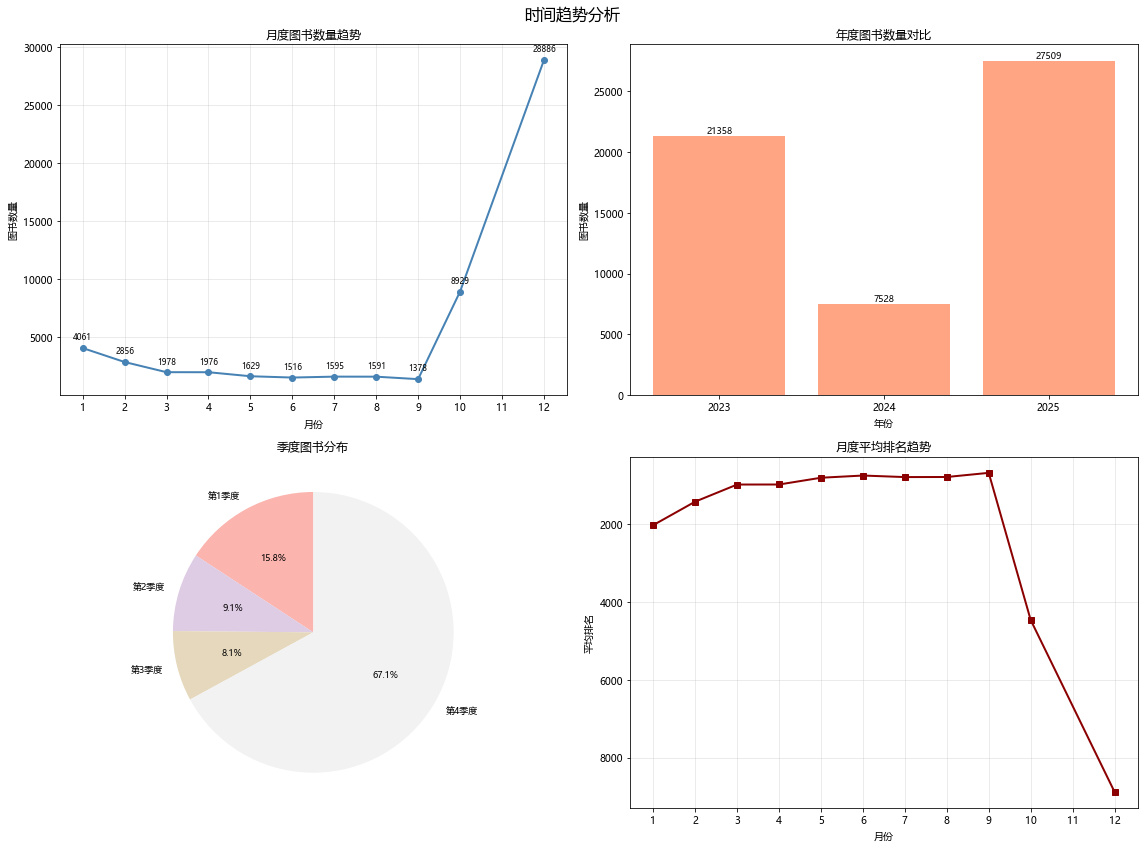


📊 时间趋势分析关键结果：
- 数据覆盖年份：2023 - 2025
- 月度最高图书数量：28886 本
✅ 时间趋势分析完成！

🎉 时间趋势分析全流程完成！
📁 图表保存路径：dang_dang_html/04_时间趋势分析.png


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
from pathlib import Path

class BookAnalysis:
    def __init__(self, data_path):
        """初始化分析类"""
        self.data_path = data_path
        self.data = None
        self.analysis_results = {}
        self.output_dir = "dang_dang_html"
        self.font_prop = None  # 中文字体对象
        
        # 初始化配置（编码适配+中文显示）
        self._init_config()
        
    def _init_config(self):
        """初始化配置：创建目录、设置中文字体"""
        # 创建输出目录
        Path(self.output_dir).mkdir(parents=True, exist_ok=True)
        
        # 解决中文显示问题
        font_path = 'C:/Windows/Fonts/msyh.ttc'  # Windows默认微软雅黑路径
        if os.path.exists(font_path):
            self.font_prop = mpl.font_manager.FontProperties(fname=font_path)
            plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示异常
            print(f"成功加载中文字体：{self.font_prop.get_name()}")
        else:
            # 兼容其他系统中文字体
            fallback_fonts = ['SimHei', 'Microsoft YaHei', 'Heiti TC', 'DejaVu Sans']
            for font in fallback_fonts:
                try:
                    plt.rcParams['font.family'] = font
                    plt.rcParams['axes.unicode_minus'] = False
                    print(f"成功加载 fallback 中文字体：{font}")
                    break
                except:
                    continue
    
    def load_data(self):
        """加载数据（指定gbk编码，解决编码错误）"""
        print(f"\n正在读取数据文件：{self.data_path}")
        try:
            # 明确使用gbk编码（适配中文CSV）
            self.data = pd.read_csv(self.data_path, encoding='gbk')
            print(f"数据读取成功！编码：gbk，数据形状：{self.data.shape}")
            
            # 预处理时间字段（确保月份/年份/季度为数值类型）
            time_cols = ['月份', '年份', '季度']
            for col in time_cols:
                if col in self.data.columns:
                    self.data[col] = pd.to_numeric(self.data[col], errors='coerce')
            return True
        except Exception as e:
            # 编码容错：尝试其他常见中文编码
            print(f"gbk编码读取失败，尝试其他编码：{str(e)[:80]}")
            try:
                self.data = pd.read_csv(self.data_path, encoding='gb18030')
                print("使用gb18030编码读取成功")
                return True
            except:
                print("所有中文编码尝试失败，分析终止")
                return False
    
    def _save_plot(self, filename, fig):
        """保存图表到指定目录"""
        filepath = os.path.join(self.output_dir, filename)
        fig.savefig(filepath, dpi=150, bbox_inches='tight')
        print(f"图表已保存：{filepath}")
    
    def plot_time_analysis(self):
        """时间趋势分析（中文显示+数据优化）"""
        print("\n⏰ 生成时间趋势分析图...")
        
        if self.data is None:
            print("❌ 数据未加载，无法进行时间趋势分析")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('时间趋势分析', fontsize=16, fontweight='bold', fontproperties=self.font_prop)

        # 1. 月度图书数量趋势
        if '月份' in self.data.columns:
            monthly_counts = self.data['月份'].dropna().value_counts().sort_index()
            # 过滤无效月份（仅保留1-12月）
            monthly_counts = monthly_counts[(monthly_counts.index >= 1) & (monthly_counts.index <= 12)]
            
            axes[0, 0].plot(monthly_counts.index, monthly_counts.values, 
                          marker='o', linewidth=2, color='steelblue')
            axes[0, 0].set_title('月度图书数量趋势', fontsize=12, fontproperties=self.font_prop)
            axes[0, 0].set_xlabel('月份', fontsize=10, fontproperties=self.font_prop)
            axes[0, 0].set_ylabel('图书数量', fontsize=10, fontproperties=self.font_prop)
            axes[0, 0].grid(True, alpha=0.3)
            axes[0, 0].set_xticks(range(1, 13))  # 显示1-12月
            
            # 添加数值标签（避免拥挤）
            for i, (x, y) in enumerate(zip(monthly_counts.index, monthly_counts.values)):
                if i % 1 == 0:  # 每个点都标注，确保信息完整
                    axes[0, 0].annotate(
                        str(y), (x, y), textcoords="offset points",
                        xytext=(0, 8), ha='center', fontsize=8, fontproperties=self.font_prop
                    )

        # 2. 年度图书数量对比
        if '年份' in self.data.columns:
            yearly_counts = self.data['年份'].dropna().value_counts().sort_index()
            # 过滤异常年份（仅保留合理范围，可根据数据调整）
            yearly_counts = yearly_counts[(yearly_counts.index >= 2000) & (yearly_counts.index <= 2030)]
            
            bars = axes[0, 1].bar(
                yearly_counts.index.astype(str),  # 年份转为字符串，避免轴标签异常
                yearly_counts.values, alpha=0.7, color='coral'
            )
            axes[0, 1].set_title('年度图书数量对比', fontsize=12, fontproperties=self.font_prop)
            axes[0, 1].set_xlabel('年份', fontsize=10, fontproperties=self.font_prop)
            axes[0, 1].set_ylabel('图书数量', fontsize=10, fontproperties=self.font_prop)
            
            # 添加数值标签
            for i, v in enumerate(yearly_counts.values):
                axes[0, 1].text(
                    i, v + 5, str(v), ha='center', va='bottom', 
                    fontsize=9, fontproperties=self.font_prop
                )

        # 3. 季度图书分布
        if '季度' in self.data.columns:
            quarterly_counts = self.data['季度'].dropna().value_counts().sort_index()
            # 过滤无效季度（仅保留1-4季度）
            quarterly_counts = quarterly_counts[(quarterly_counts.index >= 1) & (quarterly_counts.index <= 4)]
            labels = [f'第{int(q)}季度' for q in quarterly_counts.index]
            
            # 饼图文本中文适配
            wedges, texts, autotexts = axes[1, 0].pie(
                quarterly_counts.values,
                labels=labels,
                autopct='%1.1f%%',
                startangle=90,
                colors=plt.cm.Pastel1(np.linspace(0, 1, len(labels))),
                textprops={'fontsize': 9, 'fontproperties': self.font_prop}
            )
            for autotext in autotexts:
                autotext.set_color('black')  # 优化百分比可读性
            
            axes[1, 0].set_title('季度图书分布', fontsize=12, fontproperties=self.font_prop)

        # 4. 月度平均排名趋势
        if '月份' in self.data.columns and '排序' in self.data.columns:
            # 筛选有效数据
            valid_data = self.data.dropna(subset=['月份', '排序'])
            valid_data = valid_data[(valid_data['月份'] >= 1) & (valid_data['月份'] <= 12)]
            
            monthly_avg_rank = valid_data.groupby('月份')['排序'].mean().sort_index()
            axes[1, 1].plot(
                monthly_avg_rank.index, monthly_avg_rank.values,
                marker='s', color='darkred', linewidth=2
            )
            axes[1, 1].set_title('月度平均排名趋势', fontsize=12, fontproperties=self.font_prop)
            axes[1, 1].set_xlabel('月份', fontsize=10, fontproperties=self.font_prop)
            axes[1, 1].set_ylabel('平均排名', fontsize=10, fontproperties=self.font_prop)
            axes[1, 1].grid(True, alpha=0.3)
            axes[1, 1].invert_yaxis()  # 排名越小越靠前，反转y轴更直观
            axes[1, 1].set_xticks(range(1, 13))  # 显示1-12月

        plt.tight_layout()
        self._save_plot('04_时间趋势分析.png', fig)
        plt.show()
        
        # 输出时间分析关键结果
        print(f"\n📊 时间趋势分析关键结果：")
        if '年份' in self.data.columns:
            valid_years = self.data['年份'].dropna()
            print(f"- 数据覆盖年份：{valid_years.min():.0f} - {valid_years.max():.0f}")
        if '月份' in self.data.columns:
            valid_months = self.data['月份'].dropna()
            print(f"- 月度最高图书数量：{valid_months.value_counts().max()} 本")
        
        print("✅ 时间趋势分析完成！")


# 主程序入口（直接运行即可）
if __name__ == "__main__":
    # 数据文件路径（根据实际情况调整）
    DATA_FILE = "../dangdang_analysis_data/featured_dangdang_data.csv"
    
    # 初始化分析实例
    analyzer = BookAnalysis(DATA_FILE)
    
    # 加载数据（自动处理编码问题）
    if analyzer.load_data():
        # 执行时间趋势分析（自动处理中文显示）
        analyzer.plot_time_analysis()
        
        print("\n" + "="*60)
        print("🎉 时间趋势分析全流程完成！")
        print(f"📁 图表保存路径：{analyzer.output_dir}/04_时间趋势分析.png")
        print("="*60)
    else:
        print("❌ 程序执行失败：数据加载失败（编码错误或文件路径错误）")

成功加载中文字体：Microsoft YaHei

正在读取数据文件：../dangdang_analysis_data/featured_dangdang_data.csv
数据读取成功！编码：gbk，数据形状：(56395, 52)

🔗 生成相关性热力图...
图表已保存：dang_dang_html\05_相关性热力图.png


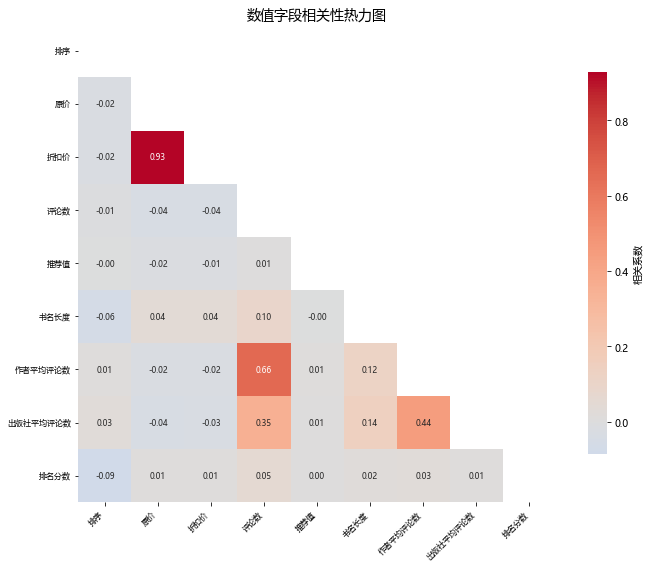


📊 强相关性字段对（|相关系数| > 0.5）：
1. 原价 ↔ 折扣价：0.928
2. 评论数 ↔ 作者平均评论数：0.659
✅ 相关性热力图分析完成！

🎉 相关性热力图分析全流程完成！
📁 图表保存路径：dang_dang_html/05_相关性热力图.png


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
from pathlib import Path

class BookAnalysis:
    def __init__(self, data_path):
        """初始化分析类"""
        self.data_path = data_path
        self.data = None
        self.analysis_results = {}
        self.output_dir = "dang_dang_html"
        self.font_prop = None  # 中文字体对象
        
        # 初始化配置（编码适配+中文显示）
        self._init_config()
        
    def _init_config(self):
        """初始化配置：创建目录、设置中文字体"""
        # 创建输出目录
        Path(self.output_dir).mkdir(parents=True, exist_ok=True)
        
        # 解决中文显示问题
        font_path = 'C:/Windows/Fonts/msyh.ttc'  # Windows默认微软雅黑路径
        if os.path.exists(font_path):
            self.font_prop = mpl.font_manager.FontProperties(fname=font_path)
            plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示异常
            print(f"成功加载中文字体：{self.font_prop.get_name()}")
        else:
            # 兼容其他系统中文字体
            fallback_fonts = ['SimHei', 'Microsoft YaHei', 'Heiti TC', 'DejaVu Sans']
            for font in fallback_fonts:
                try:
                    plt.rcParams['font.family'] = font
                    plt.rcParams['axes.unicode_minus'] = False
                    print(f"成功加载 fallback 中文字体：{font}")
                    break
                except:
                    continue
    
    def load_data(self):
        """加载数据（指定gbk编码，解决编码错误）"""
        print(f"\n正在读取数据文件：{self.data_path}")
        try:
            # 明确使用gbk编码（适配中文CSV）
            self.data = pd.read_csv(self.data_path, encoding='gbk')
            print(f"数据读取成功！编码：gbk，数据形状：{self.data.shape}")
            return True
        except Exception as e:
            # 编码容错：尝试其他常见中文编码
            print(f"gbk编码读取失败，尝试其他编码：{str(e)[:80]}")
            try:
                self.data = pd.read_csv(self.data_path, encoding='gb18030')
                print("使用gb18030编码读取成功")
                return True
            except:
                print("所有中文编码尝试失败，分析终止")
                return False
    
    def _save_plot(self, filename, fig):
        """保存图表到指定目录"""
        filepath = os.path.join(self.output_dir, filename)
        fig.savefig(filepath, dpi=150, bbox_inches='tight')
        print(f"图表已保存：{filepath}")
    
    def plot_correlation_heatmap(self):
        """数值字段相关性热力图（中文显示+数据优化）"""
        print("\n🔗 生成相关性热力图...")
        
        if self.data is None:
            print("❌ 数据未加载，无法生成相关性热力图")
            return
        
        # 选择数值字段
        numeric_columns = self.data.select_dtypes(include=[np.number]).columns

        # 排除标识性字段
        exclude_cols = ['时间序号', '图书类别_编码', '价格区间_编码', '销量等级_编码']
        numeric_columns = [col for col in numeric_columns if col not in exclude_cols]

        # 只选择部分重要字段避免热力图过大
        important_cols = ['排序', '原价', '折扣价', '评论数', '推荐值', '书名长度',
                          '作者平均评论数', '出版社平均评论数', '排名分数']
        numeric_columns = [col for col in numeric_columns if col in important_cols and col in self.data.columns]

        if len(numeric_columns) > 1:
            # 计算相关性矩阵（删除含缺失值的行，提升准确性）
            correlation_matrix = self.data[numeric_columns].dropna().corr()

            fig, ax = plt.subplots(figsize=(10, 8))
            mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # 只显示下三角

            # 绘制热力图（修正重复的cbar_kws参数，中文适配）
            sns.heatmap(
                correlation_matrix,
                mask=mask,
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                center=0,
                square=True,
                cbar_kws={"shrink": .8, "label": "相关系数"},  # 合并cbar_kws参数
                ax=ax,
                annot_kws={'fontsize': 8, 'fontproperties': self.font_prop}  # 相关系数文本字体
            )
            
            # 单独设置颜色条标签字体
            cbar = ax.collections[0].colorbar
            cbar.set_label('相关系数', fontproperties=self.font_prop, fontsize=10)
            
            # 设置标题和轴标签字体
            ax.set_title('数值字段相关性热力图', fontsize=14, fontweight='bold', fontproperties=self.font_prop)
            ax.set_xticklabels(ax.get_xticklabels(), fontproperties=self.font_prop, rotation=45, ha='right')
            ax.set_yticklabels(ax.get_yticklabels(), fontproperties=self.font_prop, rotation=0)
            ax.tick_params(axis='x', labelsize=8)
            ax.tick_params(axis='y', labelsize=8)

            plt.tight_layout()
            self._save_plot('05_相关性热力图.png', fig)
            plt.show()

            # 保存强相关性对（|r| > 0.5）
            strong_correlations = []
            for i in range(len(correlation_matrix.columns)):
                for j in range(i + 1, len(correlation_matrix.columns)):
                    corr_value = correlation_matrix.iloc[i, j]
                    if abs(corr_value) > 0.5:
                        strong_correlations.append({
                            'feature1': correlation_matrix.columns[i],
                            'feature2': correlation_matrix.columns[j],
                            'correlation': round(corr_value, 3)
                        })

            self.analysis_results['strong_correlations'] = strong_correlations
            
            # 输出强相关性结果
            print(f"\n📊 强相关性字段对（|相关系数| > 0.5）：")
            if strong_correlations:
                for idx, corr in enumerate(strong_correlations, 1):
                    print(f"{idx}. {corr['feature1']} ↔ {corr['feature2']}：{corr['correlation']}")
            else:
                print("未发现强相关性字段对")
        
        else:
            print(f"❌ 有效数值字段不足（仅找到 {len(numeric_columns)} 个），无法生成热力图")
        
        print("✅ 相关性热力图分析完成！")


# 主程序入口（直接运行即可）
if __name__ == "__main__":
    # 数据文件路径（根据实际情况调整）
    DATA_FILE = "../dangdang_analysis_data/featured_dangdang_data.csv"
    
    # 初始化分析实例
    analyzer = BookAnalysis(DATA_FILE)
    
    # 加载数据（自动处理编码问题）
    if analyzer.load_data():
        # 执行相关性热力图分析（自动处理中文显示）
        analyzer.plot_correlation_heatmap()
        
        print("\n" + "="*60)
        print("🎉 相关性热力图分析全流程完成！")
        print(f"📁 图表保存路径：{analyzer.output_dir}/05_相关性热力图.png")
        print("="*60)
    else:
        print("❌ 程序执行失败：数据加载失败（编码错误或文件路径错误）")

成功加载中文字体：Microsoft YaHei

正在读取数据文件：../dangdang_analysis_data/featured_dangdang_data.csv
数据读取成功！编码：gbk，数据形状：(56395, 52)

👤 生成作者分布图...
图表已保存：dang_dang_html\06_最多产作者分布.png


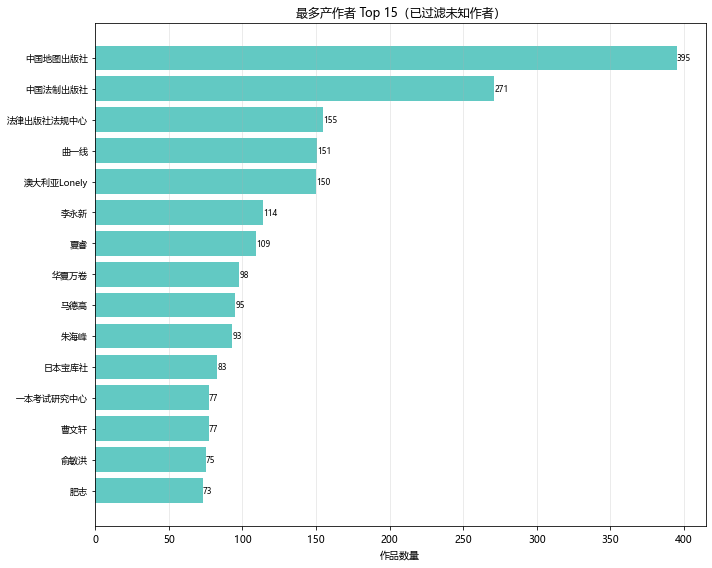


📊 Top5 最多产作者：
1. 中国地图出版社：395 部作品
2. 中国法制出版社：271 部作品
3. 法律出版社法规中心：155 部作品
4. 曲一线：151 部作品
5. 澳大利亚Lonely：150 部作品

✅ 作者分布分析完成！共统计 28783 位有效作者

🎉 作者分布分析全流程完成！
📁 图表保存路径：dang_dang_html/06_最多产作者分布.png


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
from pathlib import Path

class BookAnalysis:
    def __init__(self, data_path):
        """初始化分析类"""
        self.data_path = data_path
        self.data = None
        self.analysis_results = {}
        self.output_dir = "dang_dang_html"
        self.font_prop = None  # 中文字体对象
        
        # 初始化配置（编码适配+中文显示）
        self._init_config()
        
    def _init_config(self):
        """初始化配置：创建目录、设置中文字体"""
        # 创建输出目录
        Path(self.output_dir).mkdir(parents=True, exist_ok=True)
        
        # 解决中文显示问题
        font_path = 'C:/Windows/Fonts/msyh.ttc'  # Windows默认微软雅黑路径
        if os.path.exists(font_path):
            self.font_prop = mpl.font_manager.FontProperties(fname=font_path)
            plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示异常
            print(f"成功加载中文字体：{self.font_prop.get_name()}")
        else:
            # 兼容其他系统中文字体
            fallback_fonts = ['SimHei', 'Microsoft YaHei', 'Heiti TC', 'DejaVu Sans']
            for font in fallback_fonts:
                try:
                    plt.rcParams['font.family'] = font
                    plt.rcParams['axes.unicode_minus'] = False
                    print(f"成功加载 fallback 中文字体：{font}")
                    break
                except:
                    continue
    
    def load_data(self):
        """加载数据（指定gbk编码，解决编码错误）"""
        print(f"\n正在读取数据文件：{self.data_path}")
        try:
            # 明确使用gbk编码（适配中文CSV）
            self.data = pd.read_csv(self.data_path, encoding='gbk')
            print(f"数据读取成功！编码：gbk，数据形状：{self.data.shape}")
            return True
        except Exception as e:
            # 编码容错：尝试其他常见中文编码
            print(f"gbk编码读取失败，尝试其他编码：{str(e)[:80]}")
            try:
                self.data = pd.read_csv(self.data_path, encoding='gb18030')
                print("使用gb18030编码读取成功")
                return True
            except:
                print("所有中文编码尝试失败，分析终止")
                return False
    
    def _save_plot(self, filename, fig):
        """保存图表到指定目录"""
        filepath = os.path.join(self.output_dir, filename)
        fig.savefig(filepath, dpi=150, bbox_inches='tight')
        print(f"图表已保存：{filepath}")
    
    def plot_author_distribution(self):
        """作者作品数量分布（中文显示+过滤未知作者）"""
        print("\n👤 生成作者分布图...")
        
        if self.data is None:
            print("❌ 数据未加载，无法进行作者分布分析")
            return
        
        if '作者' in self.data.columns:
            # 处理缺失值 + 过滤“未知”作者（兼容中英文/空格）
            author_data = self.data['作者'].dropna()
            unknown_keywords = ['未知', '未知名', 'unknown', 'UNKNOWN', 'Unknown', '']
            valid_author_data = author_data[~author_data.str.strip().isin(unknown_keywords)]
            
            if len(valid_author_data) == 0:
                print("❌ 过滤未知作者后无有效数据，无法生成图表")
                return
            
            # 统计作者作品数量，取Top15
            author_counts = valid_author_data.value_counts()
            top_authors = author_counts.head(15)

            fig, ax = plt.subplots(figsize=(10, 8))
            bars = ax.barh(
                range(len(top_authors)), 
                top_authors.values,
                color='lightseagreen', alpha=0.7
            )
            
            # 设置y轴作者名称（中文适配）
            ax.set_yticks(range(len(top_authors)))
            ax.set_yticklabels(top_authors.index, fontsize=9, fontproperties=self.font_prop)
            # 设置轴标签和标题（中文适配）
            ax.set_xlabel('作品数量', fontsize=10, fontproperties=self.font_prop)
            ax.set_title('最多产作者 Top 15（已过滤未知作者）', fontsize=12, fontproperties=self.font_prop)
            ax.invert_yaxis()  # 反转y轴，作品数最多的在顶部
            ax.grid(True, axis='x', alpha=0.3)

            # 添加数值标签（中文适配）
            for i, v in enumerate(top_authors.values):
                ax.text(
                    v + 0.1, i, str(v), 
                    va='center', fontsize=8, fontproperties=self.font_prop
                )

            plt.tight_layout()
            self._save_plot('06_最多产作者分布.png', fig)
            plt.show()
            
            # 输出Top5作者统计
            print(f"\n📊 Top5 最多产作者：")
            for idx, (author, count) in enumerate(top_authors.head(5).items(), 1):
                print(f"{idx}. {author}：{count} 部作品")
            
            print(f"\n✅ 作者分布分析完成！共统计 {len(author_counts)} 位有效作者")
        else:
            print("❌ 数据中缺少'作者'字段，无法进行分析")


# 主程序入口（直接运行即可）
if __name__ == "__main__":
    # 数据文件路径（根据实际情况调整）
    DATA_FILE = "../dangdang_analysis_data/featured_dangdang_data.csv"
    
    # 初始化分析实例
    analyzer = BookAnalysis(DATA_FILE)
    
    # 加载数据（自动处理编码问题）
    if analyzer.load_data():
        # 执行作者分布分析（自动处理中文显示+过滤未知作者）
        analyzer.plot_author_distribution()
        
        print("\n" + "="*60)
        print("🎉 作者分布分析全流程完成！")
        print(f"📁 图表保存路径：{analyzer.output_dir}/06_最多产作者分布.png")
        print("="*60)
    else:
        print("❌ 程序执行失败：数据加载失败（编码错误或文件路径错误）")

成功加载中文字体：Microsoft YaHei

正在读取数据文件：../dangdang_analysis_data/featured_dangdang_data.csv
数据读取成功！编码：gbk，数据形状：(56395, 52)

🏢 生成出版社分布图...
图表已保存：dang_dang_html\07_出版社图书分布.png


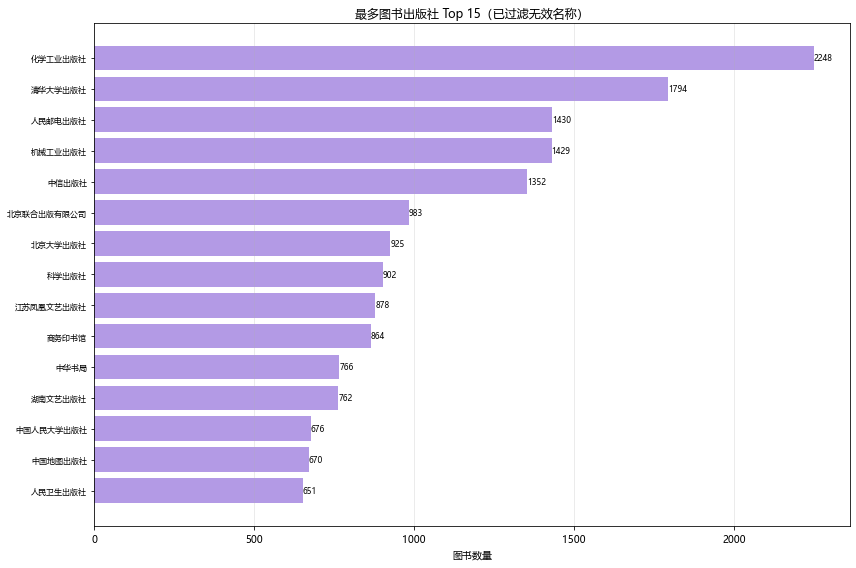


📊 Top5 最多图书出版社：
1. 化学工业出版社：2248 部图书
2. 清华大学出版社：1794 部图书
3. 人民邮电出版社：1430 部图书
4. 机械工业出版社：1429 部图书
5. 中信出版社：1352 部图书

✅ 出版社分布分析完成！共统计 15 家有效出版社

🎉 出版社分布分析全流程完成！
📁 图表保存路径：dang_dang_html/07_出版社图书分布.png


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
from pathlib import Path

class BookAnalysis:
    def __init__(self, data_path):
        """初始化分析类"""
        self.data_path = data_path
        self.data = None
        self.analysis_results = {}
        self.output_dir = "dang_dang_html"
        self.font_prop = None  # 中文字体对象
        
        # 初始化配置（编码适配+中文显示）
        self._init_config()
        
    def _init_config(self):
        """初始化配置：创建目录、设置中文字体"""
        # 创建输出目录
        Path(self.output_dir).mkdir(parents=True, exist_ok=True)
        
        # 解决中文显示问题
        font_path = 'C:/Windows/Fonts/msyh.ttc'  # Windows默认微软雅黑路径
        if os.path.exists(font_path):
            self.font_prop = mpl.font_manager.FontProperties(fname=font_path)
            plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示异常
            print(f"成功加载中文字体：{self.font_prop.get_name()}")
        else:
            # 兼容其他系统中文字体
            fallback_fonts = ['SimHei', 'Microsoft YaHei', 'Heiti TC', 'DejaVu Sans']
            for font in fallback_fonts:
                try:
                    plt.rcParams['font.family'] = font
                    plt.rcParams['axes.unicode_minus'] = False
                    print(f"成功加载 fallback 中文字体：{font}")
                    break
                except:
                    continue
    
    def load_data(self):
        """加载数据（指定gbk编码，解决编码错误）"""
        print(f"\n正在读取数据文件：{self.data_path}")
        try:
            # 明确使用gbk编码（适配中文CSV）
            self.data = pd.read_csv(self.data_path, encoding='gbk')
            print(f"数据读取成功！编码：gbk，数据形状：{self.data.shape}")
            return True
        except Exception as e:
            # 编码容错：尝试其他常见中文编码
            print(f"gbk编码读取失败，尝试其他编码：{str(e)[:80]}")
            try:
                self.data = pd.read_csv(self.data_path, encoding='gb18030')
                print("使用gb18030编码读取成功")
                return True
            except:
                print("所有中文编码尝试失败，分析终止")
                return False
    
    def _save_plot(self, filename, fig):
        """保存图表到指定目录"""
        filepath = os.path.join(self.output_dir, filename)
        fig.savefig(filepath, dpi=150, bbox_inches='tight')
        print(f"图表已保存：{filepath}")
    
    def plot_publisher_distribution(self):
        """出版社图书数量分布（中文显示+过滤无效名称）"""
        print("\n🏢 生成出版社分布图...")
        
        if self.data is None:
            print("❌ 数据未加载，无法进行出版社分布分析")
            return
        
        if '出版社' in self.data.columns:
            # 处理缺失值 + 过滤无效出版社名称
            publisher_data = self.data['出版社'].dropna()
            # 过滤关键词（可根据实际数据补充）
            invalid_keywords = ['未知', '未知名', 'unknown', 'UNKNOWN', '无', '']
            valid_publisher_data = publisher_data[~publisher_data.str.strip().isin(invalid_keywords)]
            
            if len(valid_publisher_data) == 0:
                print("❌ 过滤无效出版社后无有效数据，无法生成图表")
                return
            
            # 统计出版社图书数量，取Top15
            publisher_counts = valid_publisher_data.value_counts().head(15)

            fig, ax = plt.subplots(figsize=(12, 8))  # 加宽图表，适配长出版社名称
            bars = ax.barh(
                range(len(publisher_counts)),
                publisher_counts.values,
                color='mediumpurple', alpha=0.7
            )
            
            # 设置y轴出版社名称（中文适配，缩小字体避免重叠）
            ax.set_yticks(range(len(publisher_counts)))
            ax.set_yticklabels(publisher_counts.index, fontsize=8, fontproperties=self.font_prop)
            # 设置轴标签和标题（中文适配）
            ax.set_xlabel('图书数量', fontsize=10, fontproperties=self.font_prop)
            ax.set_title('最多图书出版社 Top 15（已过滤无效名称）', fontsize=12, fontproperties=self.font_prop)
            ax.invert_yaxis()  # 反转y轴，图书数最多的在顶部
            ax.grid(True, axis='x', alpha=0.3)

            # 添加数值标签（中文适配）
            for i, v in enumerate(publisher_counts.values):
                ax.text(
                    v + 0.1, i, str(v),
                    va='center', fontsize=8, fontproperties=self.font_prop
                )

            plt.tight_layout()
            self._save_plot('07_出版社图书分布.png', fig)
            plt.show()
            
            # 输出Top5出版社统计
            print(f"\n📊 Top5 最多图书出版社：")
            for idx, (publisher, count) in enumerate(publisher_counts.head(5).items(), 1):
                print(f"{idx}. {publisher}：{count} 部图书")
            
            print(f"\n✅ 出版社分布分析完成！共统计 {len(publisher_counts)} 家有效出版社")
        else:
            print("❌ 数据中缺少'出版社'字段，无法进行分析")


# 主程序入口（直接运行即可）
if __name__ == "__main__":
    # 数据文件路径（根据实际情况调整）
    DATA_FILE = "../dangdang_analysis_data/featured_dangdang_data.csv"
    
    # 初始化分析实例
    analyzer = BookAnalysis(DATA_FILE)
    
    # 加载数据（自动处理编码问题）
    if analyzer.load_data():
        # 执行出版社分布分析（自动处理中文显示+过滤无效名称）
        analyzer.plot_publisher_distribution()
        
        print("\n" + "="*60)
        print("🎉 出版社分布分析全流程完成！")
        print(f"📁 图表保存路径：{analyzer.output_dir}/07_出版社图书分布.png")
        print("="*60)
    else:
        print("❌ 程序执行失败：数据加载失败（编码错误或文件路径错误）")

成功加载中文字体：Microsoft YaHei

正在读取数据文件：../dangdang_analysis_data/featured_dangdang_data.csv
数据读取成功！编码：gbk，数据形状：(56395, 52)

📊 生成价格评论数关系图...
图表已保存：dang_dang_html\08_价格评论数关系.png


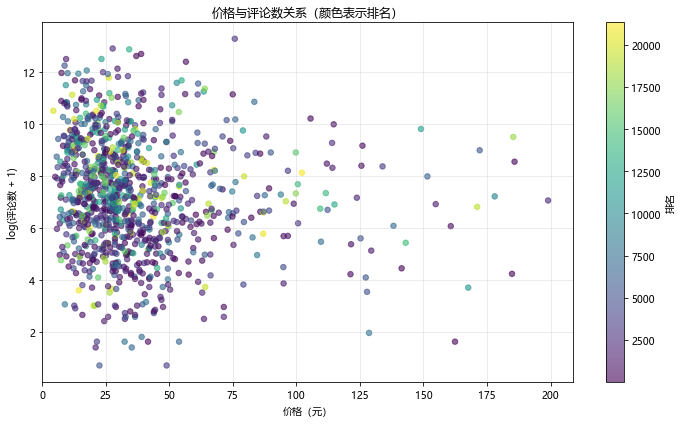


📊 分析数据统计：
- 有效数据总数：55636 条
- 抽样数据量：1000 条
- 价格范围：1.3 - 200.0 元
- 评论数范围：1 - 991374 条
✅ 价格与评论数关系分析完成！

🎉 价格与评论数关系分析全流程完成！
📁 图表保存路径：dang_dang_html/08_价格评论数关系.png


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
from pathlib import Path

class BookAnalysis:
    def __init__(self, data_path):
        """初始化分析类"""
        self.data_path = data_path
        self.data = None
        self.analysis_results = {}
        self.output_dir = "dang_dang_html"
        self.font_prop = None  # 中文字体对象
        
        # 初始化配置（编码适配+中文显示）
        self._init_config()
        
    def _init_config(self):
        """初始化配置：创建目录、设置中文字体"""
        # 创建输出目录
        Path(self.output_dir).mkdir(parents=True, exist_ok=True)
        
        # 解决中文显示问题
        font_path = 'C:/Windows/Fonts/msyh.ttc'  # Windows默认微软雅黑路径
        if os.path.exists(font_path):
            self.font_prop = mpl.font_manager.FontProperties(fname=font_path)
            plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示异常
            print(f"成功加载中文字体：{self.font_prop.get_name()}")
        else:
            # 兼容其他系统中文字体
            fallback_fonts = ['SimHei', 'Microsoft YaHei', 'Heiti TC', 'DejaVu Sans']
            for font in fallback_fonts:
                try:
                    plt.rcParams['font.family'] = font
                    plt.rcParams['axes.unicode_minus'] = False
                    print(f"成功加载 fallback 中文字体：{font}")
                    break
                except:
                    continue
    
    def load_data(self):
        """加载数据（指定gbk编码，解决编码错误）"""
        print(f"\n正在读取数据文件：{self.data_path}")
        try:
            # 明确使用gbk编码（适配中文CSV）
            self.data = pd.read_csv(self.data_path, encoding='gbk')
            print(f"数据读取成功！编码：gbk，数据形状：{self.data.shape}")
            return True
        except Exception as e:
            # 编码容错：尝试其他常见中文编码
            print(f"gbk编码读取失败，尝试其他编码：{str(e)[:80]}")
            try:
                self.data = pd.read_csv(self.data_path, encoding='gb18030')
                print("使用gb18030编码读取成功")
                return True
            except:
                print("所有中文编码尝试失败，分析终止")
                return False
    
    def _save_plot(self, filename, fig):
        """保存图表到指定目录"""
        filepath = os.path.join(self.output_dir, filename)
        fig.savefig(filepath, dpi=150, bbox_inches='tight')
        print(f"图表已保存：{filepath}")
    
    def plot_price_comments_relationship(self):
        """价格与评论数关系（中文显示+数据优化）"""
        print("\n📊 生成价格评论数关系图...")
        
        if self.data is None:
            print("❌ 数据未加载，无法进行价格与评论数关系分析")
            return
        
        if '原价' in self.data.columns and '评论数' in self.data.columns:
            # 筛选有效数据（去除缺失值和异常值）
            valid_data = self.data.dropna(subset=['原价', '评论数'])
            # 过滤价格异常值（保留≤200元，使图表更清晰）
            valid_data = valid_data[(valid_data['原价'] >= 0) & (valid_data['原价'] <= 200)]
            
            if len(valid_data) == 0:
                print("❌ 筛选后无有效数据，无法生成图表")
                return
            
            # 抽样（最多1000条，避免点过密）
            sample_size = min(1000, len(valid_data))
            sample_data = valid_data.sample(sample_size, random_state=42)  # 固定种子，结果可复现
            
            # 对数变换评论数（改善分布偏态）
            log_comments = np.log1p(sample_data['评论数'])
            
            fig, ax = plt.subplots(figsize=(10, 6))
            # 绘制散点图（颜色表示排名，无排名则用默认颜色）
            if '排序' in sample_data.columns:
                scatter = ax.scatter(
                    sample_data['原价'],
                    log_comments,
                    c=sample_data['排序'],
                    cmap='viridis',
                    alpha=0.6,
                    s=30
                )
                # 设置颜色条（中文适配）
                cbar = plt.colorbar(scatter, ax=ax)
                cbar.set_label('排名', fontproperties=self.font_prop, fontsize=10)
                title = '价格与评论数关系（颜色表示排名）'
            else:
                ax.scatter(
                    sample_data['原价'],
                    log_comments,
                    alpha=0.6,
                    s=30,
                    color='steelblue'
                )
                title = '价格与评论数关系'
            
            # 设置轴标签和标题（中文适配）
            ax.set_xlabel('价格（元）', fontsize=10, fontproperties=self.font_prop)
            ax.set_ylabel('log(评论数 + 1)', fontsize=10, fontproperties=self.font_prop)
            ax.set_title(title, fontsize=12, fontproperties=self.font_prop)
            
            # 优化图表可读性
            ax.grid(True, alpha=0.3)
            ax.set_xlim(left=0)  # 价格从0开始，更符合实际意义
            
            plt.tight_layout()
            self._save_plot('08_价格评论数关系.png', fig)
            plt.show()
            
            # 输出关键统计信息
            print(f"\n📊 分析数据统计：")
            print(f"- 有效数据总数：{len(valid_data)} 条")
            print(f"- 抽样数据量：{sample_size} 条")
            print(f"- 价格范围：{valid_data['原价'].min():.1f} - {valid_data['原价'].max():.1f} 元")
            print(f"- 评论数范围：{valid_data['评论数'].min()} - {valid_data['评论数'].max()} 条")
            
            print("✅ 价格与评论数关系分析完成！")
        else:
            print("❌ 数据中缺少'原价'或'评论数'字段，无法进行分析")


# 主程序入口（直接运行即可）
if __name__ == "__main__":
    # 数据文件路径（根据实际情况调整）
    DATA_FILE = "../dangdang_analysis_data/featured_dangdang_data.csv"
    
    # 初始化分析实例
    analyzer = BookAnalysis(DATA_FILE)
    
    # 加载数据（自动处理编码问题）
    if analyzer.load_data():
        # 执行价格与评论数关系分析（自动处理中文显示）
        analyzer.plot_price_comments_relationship()
        
        print("\n" + "="*60)
        print("🎉 价格与评论数关系分析全流程完成！")
        print(f"📁 图表保存路径：{analyzer.output_dir}/08_价格评论数关系.png")
        print("="*60)
    else:
        print("❌ 程序执行失败：数据加载失败（编码错误或文件路径错误）")